# Settings

In [1]:
library(dplyr)
library(gplots)
library(RColorBrewer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




In [2]:
# Input files
# - rowdata gene table from
rowdata.file <- "../rowdata_human.rds"
# - rowdata column to use for matching
match.col <- "gene_id_base"
# - unformatted expression data 
expr.file <- "../../input_data/Cardoso-Moreira/Human.RPKM.txt"


# Output files
out.files <- list("coldata" = "coldata_human.rds",
                  "exprmat" = "exprmat_human.rds",
                  "layout" = "layout_human.rds")

# Load input data

In [3]:
rowdata <- readRDS(rowdata.file)
nrow(rowdata)
head(rowdata)

[1] 30696

,source,type,gene_id,gene_type,gene_name,level,tag,havana_gene,artif_dupl,gene_id_base,⋯,hom_early_adult,hem_early_adult,sucessful_procedures_13,ortholog,gene_symbol,mean_depmap_gene_effect_score,depmap_essential_05,depmap_essential_1,fusil_all,fusil
,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
HGNC:5,HAVANA,gene,ENSG00000121410.12,protein_coding,A1BG,1,overlapping_locus,OTTHUMG00000183507.3,NA,ENSG00000121410,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:37133,HAVANA,gene,ENSG00000268895.6,lncRNA,A1BG-AS1,2,overlapping_locus,OTTHUMG00000183508.2,NA,ENSG00000268895,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:24086,HAVANA,gene,ENSG00000148584.16,protein_coding,A1CF,2,overlapping_locus,OTTHUMG00000018240.6,NA,ENSG00000148584,⋯,23,0,yes,one2one,A1CF,-0.07773930,n,n,VP,VP
HGNC:7,HAVANA,gene,ENSG00000175899.15,protein_coding,A2M,2,NA,OTTHUMG00000150267.7,NA,ENSG00000175899,⋯,19,0,yes,one2one,A2M,0.02673364,n,n,VP,VP
HGNC:27057,HAVANA,gene,ENSG00000245105.5,lncRNA,A2M-AS1,2,NA,OTTHUMG00000168289.4,NA,ENSG00000245105,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:23336,HAVANA,gene,ENSG00000166535.20,protein_coding,A2ML1,2,NA,OTTHUMG00000128499.9,NA,ENSG00000166535,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [4]:
exprdata <- read.delim(expr.file, sep=" ", as.is=T)
nrow(exprdata)
head(exprdata)

[1] 51299

,Brain.4wpc.1,Brain.4wpc.2,Brain.4wpc.3,Brain.5wpc.4,Brain.5wpc.5,Brain.7wpc.6,Brain.7wpc.7,Brain.7wpc.8,Brain.8wpc.9,Brain.8wpc.10,⋯,Testis.youngTeenager.32,Testis.youngTeenager.33,Testis.oldTeenager.34,Testis.oldTeenager.35,Testis.youngAdult.36,Testis.youngAdult.37,Testis.youngAdult.38,Testis.youngMidAge.39,Testis.olderMidAge.40,Testis.Senior.41
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,44.2005665,48.5835515,54.30391168,52.5630099,51.69286604,32.0221155,32.41588223,28.24298623,17.92353911,27.11752801,⋯,16.2244822,12.1272157,21.4937670,53.86000013,30.2831786,47.02872443,20.9529291,32.21146630,29.94535557,46.00492488
ENSG00000000005,0.0348217,0.0000000,0.02918603,0.4921495,0.02775843,0.3614597,0.03105924,0.02642910,0.05889778,0.09309232,⋯,0.5467912,0.1941425,0.1001094,0.03658765,0.0425993,0.06979452,0.1592836,0.08125498,0.04977783,0.02372282
ENSG00000000419,30.1216380,21.9818231,30.17139032,34.5984609,30.88015598,22.4832242,33.97216752,22.17438890,27.33989089,31.54032432,⋯,30.0859755,32.8485787,32.6892373,37.28606040,36.7358073,46.57999018,30.3295344,46.17194629,36.69592386,36.67484966
ENSG00000000457,3.3388270,3.6586173,3.36225095,3.4741430,3.68525798,2.4677777,3.27623920,2.43200782,2.56508570,2.82639064,⋯,1.9204491,2.4547340,2.2315248,1.95968219,2.3839128,2.21709607,2.3356554,2.03574681,2.99154422,2.04410936
ENSG00000000460,9.3438235,9.3009393,10.59001800,8.3135104,10.97231059,5.5049203,5.74896526,5.67880461,3.20860350,4.19081464,⋯,2.1613485,3.2959009,3.8353520,3.42089359,3.9344013,4.96647976,5.1559725,2.66417604,5.46138145,3.39620122
ENSG00000000938,0.1613786,0.1404859,0.20289079,0.1520554,0.10291552,0.3085818,0.08636507,0.06124187,0.27295747,0.43142956,⋯,0.9122631,0.7267126,0.4732286,0.86053124,0.5133007,0.57144183,0.3598667,0.64016947,0.76128268,0.64865590


# Make coldata table

In [5]:
samples <- colnames(exprdata)

coldata <- samples %>% strsplit(split="\\.") %>%
    lapply(FUN=strsplit, split="\\.") %>%
    unlist() %>%
    matrix(ncol=3, byrow=T) %>%
    as.data.frame()
coldata <- cbind(samples, coldata)
colnames(coldata) <- c("label","tissue", "stage", "index")
rownames(coldata) <- gsub("\\.", "_", samples)
nrow(coldata)
head(coldata)
table(coldata$stage)
table(coldata$tissue)

[1] 297

,label,tissue,stage,index
,<chr>,<chr>,<chr>,<chr>
Brain_4wpc_1,Brain.4wpc.1,Brain,4wpc,1
Brain_4wpc_2,Brain.4wpc.2,Brain,4wpc,2
Brain_4wpc_3,Brain.4wpc.3,Brain,4wpc,3
Brain_5wpc_4,Brain.5wpc.4,Brain,5wpc,4
Brain_5wpc_5,Brain.5wpc.5,Brain,5wpc,5
Brain_7wpc_6,Brain.7wpc.6,Brain,7wpc,6



        10wpc         11wpc         12wpc         13wpc         16wpc 
           17            20            12            17            14 
        18wpc         19wpc         20wpc          4wpc          5wpc 
           10            10             6            16            13 
         6wpc          7wpc          8wpc          9wpc        infant 
           13            20            24            15            13 
      newborn   olderMidAge   oldTeenager        school        senior 
           14             7             2             7             6 
       Senior      teenager       toddler    youngAdult   youngMidAge 
            1             9            11            13             5 
youngTeenager 
            2 


     Brain Cerebellum      Heart     Kidney      Liver      Ovary     Testis 
        53         58         44         36         49         18         39 

In [6]:
# Add replicate column

coldata$replicate <- NA
tissues <- unique(coldata$tissue)
stages <- unique(coldata$stage)
for(t in seq(length(tissues))){
    for(s in seq(length(stages))){
        temp.match <- which(coldata$tissue==tissues[t] & coldata$stage==stages[s])
        coldata[temp.match, "replicate"] <- seq(length(temp.match))
    }
}
nrow(coldata)
head(coldata)

[1] 297

,label,tissue,stage,index,replicate
,<chr>,<chr>,<chr>,<chr>,<int>
Brain_4wpc_1,Brain.4wpc.1,Brain,4wpc,1,1
Brain_4wpc_2,Brain.4wpc.2,Brain,4wpc,2,2
Brain_4wpc_3,Brain.4wpc.3,Brain,4wpc,3,3
Brain_5wpc_4,Brain.5wpc.4,Brain,5wpc,4,1
Brain_5wpc_5,Brain.5wpc.5,Brain,5wpc,5,2
Brain_7wpc_6,Brain.7wpc.6,Brain,7wpc,6,1


# Make counts table

In [7]:
#match rowdata with exprdata

m <- match(rowdata[,match.col], rownames(exprdata))

# check matches
length(m)
length(which(is.na(m))) # how many NAs?
all(rowdata[which(!is.na(m)),match.col] == rownames(exprdata)[m[which(!is.na(m))]]) # all non-NAs match correctly?

[1] 30696

[1] 6364

[1] TRUE

In [8]:
# make exprmat

exprmat <- matrix(NA, nrow=nrow(rowdata), ncol=nrow(coldata))
rownames(exprmat) <- rownames(rowdata)
colnames(exprmat) <- rownames(coldata)
exprmat[,rownames(coldata)]  <- as.matrix(exprdata[m,coldata[rownames(coldata),"label"]])
nrow(exprmat)
head(exprmat)

[1] 30696

,Brain_4wpc_1,Brain_4wpc_2,Brain_4wpc_3,Brain_5wpc_4,Brain_5wpc_5,Brain_7wpc_6,Brain_7wpc_7,Brain_7wpc_8,Brain_8wpc_9,Brain_8wpc_10,⋯,Testis_youngTeenager_32,Testis_youngTeenager_33,Testis_oldTeenager_34,Testis_oldTeenager_35,Testis_youngAdult_36,Testis_youngAdult_37,Testis_youngAdult_38,Testis_youngMidAge_39,Testis_olderMidAge_40,Testis_Senior_41
HGNC:5,0.006997372,0.011075385,0.023459564,0.021977053,0.01115603,0.061166155,0.1560327,0.03186534,0.201202227,0.26189476,⋯,0.03296308,0.03000974,0.00000000,0.03308506,0.02568081,0.023375184,0.06401562,0.02612492,0.02000557,0.01906827
HGNC:37133,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:24086,0.002919033,0.009240444,0.004893211,0.006111984,0.00000000,0.000000000,0.0000000,0.06646494,0.019749126,0.00000000,⋯,0.02291820,0.03755671,0.02014072,0.03527129,0.02142608,0.007800978,0.04673347,0.01907203,0.01390925,0.00000000
HGNC:7,16.817125869,15.095125819,13.351968381,10.517736639,13.58093143,22.611881538,3.8224659,5.15889118,6.958914812,7.34837257,⋯,26.33141506,16.75609155,11.12377660,9.05644671,10.12550772,9.457974300,12.38748612,15.82797077,14.05168428,7.39465248
HGNC:27057,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:23336,0.019191750,0.012150621,0.012868549,0.012055330,0.01223910,0.004194023,0.0000000,0.00582649,0.006492224,0.01368192,⋯,3.85741258,3.44376558,1.50516364,1.54464217,1.31009031,1.202728264,1.43533529,1.57994925,1.46318507,0.89430773


# Average across replicates

In [9]:
exprmat.avg <- matrix(NA, nrow=nrow(exprmat), ncol=0)
coldata.avg <- as.data.frame(matrix(NA, nrow=0, ncol=4))
rownames(exprmat.avg) <- rownames(exprmat)
for(t in seq(length(tissues))){
    for(s in seq(length(stages))){
        temp.match <- which(coldata$tissue==tissues[t] & coldata$stage==stages[s])
        if(length(temp.match)==1){
            exprmat.avg <-  cbind(exprmat.avg, exprmat[,temp.match])
            colnames(exprmat.avg)[ncol(exprmat.avg)] <- paste(tissues[t], stages[s], sep="_")}
        if(length(temp.match)>1){
            exprmat.avg <-  cbind(exprmat.avg, rowMeans(exprmat[,temp.match]))
            colnames(exprmat.avg)[ncol(exprmat.avg)] <- paste(tissues[t], stages[s], sep="_")}
        if(length(temp.match)>0){
            coldata.avg <- rbind(coldata.avg, c(paste(tissues[t], stages[s], sep="_"),
                                                tissues[t], stages[s]))}
    }
}
nrow(exprmat.avg)
ncol(exprmat.avg)
head(exprmat.avg)
colnames(coldata.avg) <- c("label", "tissue", "stage")
rownames(coldata.avg) <- coldata.avg$label
nrow(coldata.avg)
head(coldata.avg)

[1] 30696

[1] 134

,Brain_4wpc,Brain_5wpc,Brain_7wpc,Brain_8wpc,Brain_9wpc,Brain_10wpc,Brain_11wpc,Brain_12wpc,Brain_13wpc,Brain_16wpc,⋯,Testis_19wpc,Testis_infant,Testis_toddler,Testis_youngAdult,Testis_youngMidAge,Testis_olderMidAge,Testis_6wpc,Testis_youngTeenager,Testis_oldTeenager,Testis_Senior
HGNC:5,0.013844107,0.016566543,0.083021414,0.208258441,0.204497825,0.46749549,0.330570390,0.75507178,0.178944586,0.61673360,⋯,0.088333661,0.18877032,0.10176675,0.03769054,0.02612492,0.02000557,0.1132155,0.03148641,0.01654253,0.01906827
HGNC:37133,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:24086,0.005684229,0.003055992,0.022154980,0.004937281,0.001296187,0.00000000,0.001337217,0.00000000,0.007786372,0.01631434,⋯,0.007369877,0.72967148,0.98028186,0.02532017,0.01907203,0.01390925,0.1308959,0.03023745,0.02770600,0.00000000
HGNC:7,15.088073356,12.049334034,10.531079535,7.838888978,7.913353569,10.82810873,13.576868320,17.61466806,15.883865651,9.93330354,⋯,66.660028601,65.91421457,57.86230879,10.65698938,15.82797077,14.05168428,19.2404004,21.54375330,10.09011165,7.39465248
HGNC:27057,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:23336,0.014736974,0.012147214,0.003340171,0.016827596,0.005830775,0.02849342,0.033583622,0.00812134,0.039775828,0.04711977,⋯,0.998166739,0.03387871,0.06089815,1.31605129,1.57994925,1.46318507,1.0533847,3.65058908,1.52490290,0.89430773


[1] 134

,label,tissue,stage
,<chr>,<chr>,<chr>
Brain_4wpc,Brain_4wpc,Brain,4wpc
Brain_5wpc,Brain_5wpc,Brain,5wpc
Brain_7wpc,Brain_7wpc,Brain,7wpc
Brain_8wpc,Brain_8wpc,Brain,8wpc
Brain_9wpc,Brain_9wpc,Brain,9wpc
Brain_10wpc,Brain_10wpc,Brain,10wpc


# format layout

In [10]:
# correct stage labeling to make consitent across tissues
coldata.avg.reformat <- coldata.avg
coldata.avg.reformat$stage[which(coldata.avg.reformat$stage=="Senior")] <- "senior"
coldata.avg.reformat$stage[which(coldata.avg.reformat$stage=="youngTeenager")] <- "school"
coldata.avg.reformat$stage[which(coldata.avg.reformat$stage=="oldTeenager")] <- "teenager"
tissues.reformat <- unique(coldata.avg.reformat$tissue)
stages.reformat <- unique(coldata.avg.reformat$stage)
tissues.reformat
stages.reformat

[1] "Brain"      "Cerebellum" "Heart"      "Kidney"     "Liver"     
[6] "Ovary"      "Testis"

[1] "4wpc"        "5wpc"        "7wpc"        "8wpc"        "9wpc"       
 [6] "10wpc"       "11wpc"       "12wpc"       "13wpc"       "16wpc"      
[11] "18wpc"       "19wpc"       "20wpc"       "newborn"     "infant"     
[16] "toddler"     "school"      "teenager"    "youngAdult"  "youngMidAge"
[21] "olderMidAge" "senior"      "6wpc"

In [11]:
# Filter tissues and/or stages in final layout [optional, not done in this case]
# - tissues to keep (all in this case)
tissues.sub <- tissues.reformat
# - stages to keep (all in this case)
stages.sub <- stages.reformat

keep.rows <- c()
for(t in seq(length(tissues.sub))){
    for(s in seq(length(stages.sub))){
        temp.match <- which(coldata.avg.reformat$tissue==tissues.sub[t] & coldata.avg.reformat$stage==stages.sub[s])
        if(length(temp.match)==1){
            keep.rows <- c(keep.rows, temp.match)}
    }
}
coldata.avg.reformat.filt <- coldata.avg.reformat[keep.rows,]
nrow(coldata.avg.reformat.filt)
coldata.avg.reformat.filt

[1] 134

,label,tissue,stage
,<chr>,<chr>,<chr>
Brain_4wpc,Brain_4wpc,Brain,4wpc
Brain_5wpc,Brain_5wpc,Brain,5wpc
Brain_7wpc,Brain_7wpc,Brain,7wpc
Brain_8wpc,Brain_8wpc,Brain,8wpc
Brain_9wpc,Brain_9wpc,Brain,9wpc
Brain_10wpc,Brain_10wpc,Brain,10wpc
Brain_11wpc,Brain_11wpc,Brain,11wpc
Brain_12wpc,Brain_12wpc,Brain,12wpc
Brain_13wpc,Brain_13wpc,Brain,13wpc


In [12]:
# order stages for display
length(stages.sub)
stages.sub
stages.sub.ord <- stages.sub[c(1,2,23,3:22)]
length(stages.sub.ord)
stages.sub.ord

[1] 23

[1] "4wpc"        "5wpc"        "7wpc"        "8wpc"        "9wpc"       
 [6] "10wpc"       "11wpc"       "12wpc"       "13wpc"       "16wpc"      
[11] "18wpc"       "19wpc"       "20wpc"       "newborn"     "infant"     
[16] "toddler"     "school"      "teenager"    "youngAdult"  "youngMidAge"
[21] "olderMidAge" "senior"      "6wpc"

[1] 23

[1] "4wpc"        "5wpc"        "6wpc"        "7wpc"        "8wpc"       
 [6] "9wpc"        "10wpc"       "11wpc"       "12wpc"       "13wpc"      
[11] "16wpc"       "18wpc"       "19wpc"       "20wpc"       "newborn"    
[16] "infant"      "toddler"     "school"      "teenager"    "youngAdult" 
[21] "youngMidAge" "olderMidAge" "senior"

In [13]:
# order tissuesfor display (no change in this case)
length(tissues.sub)
tissues.sub
tissues.sub.ord <- tissues.sub
length(tissues.sub.ord)
tissues.sub.ord

[1] 7

[1] "Brain"      "Cerebellum" "Heart"      "Kidney"     "Liver"     
[6] "Ovary"      "Testis"

[1] 7

[1] "Brain"      "Cerebellum" "Heart"      "Kidney"     "Liver"     
[6] "Ovary"      "Testis"

Warning message in heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col = my.cols, :
“Discrepancy: Rowv is FALSE, while dendrogram is `both'. Omitting row dendogram.”
Warning message in heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col = my.cols, :
“Discrepancy: Colv is FALSE, while dendrogram is `column'. Omitting column dendogram.”


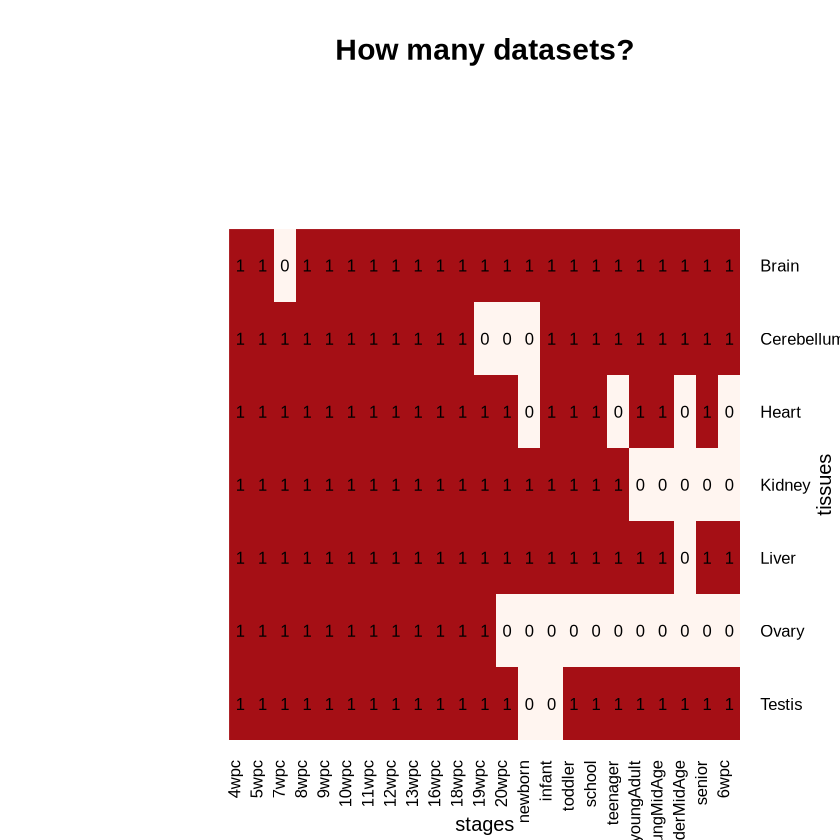

In [14]:
# plot layout as heatmap
my.cex=1
bias=1
my.pal <- c(brewer.pal(9, "Reds")[c(1,4,8)])
my.cols <- colorRampPalette(my.pal, bias=bias)(100)
layout.heatmap <- matrix(NA, nrow=length(tissues.sub.ord), ncol=length(stages.sub.ord))
for(row in seq(length(tissues.sub.ord))){
    for(col in seq(length(stages.sub.ord))){
        layout.heatmap[row, col] <- length(which(coldata.avg.reformat.filt$tissue==tissues.sub.ord[row] & 
                                                 coldata.avg.reformat.filt$stage==stages.sub.ord[col]))
    }
}
heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col=my.cols, symbreaks=F,
          tracecol=NA, cexRow=my.cex, cexCol=my.cex, 
          xlab="stages", ylab="tissues", main="How many datasets?",
          labRow=tissues.sub, labCol=stages.sub, key=F, cellnote=round(layout.heatmap, digits=1), notecex=my.cex, notecol="black")

In [15]:
# create layout matrix by sample name
layout <- matrix(NA, nrow=length(tissues.sub.ord), ncol=length(stages.sub.ord))
rownames(layout) <- tissues.sub.ord
colnames(layout) <- stages.sub.ord
for(row in seq(length(tissues.sub.ord))){
    for(col in seq(length(stages.sub.ord))){
        temp.match <- which(coldata.avg.reformat.filt$tissue==tissues.sub.ord[row] & 
                            coldata.avg.reformat.filt$stage==stages.sub.ord[col])
         if(length(temp.match) == 1){
              layout[row, col] <- coldata.avg.reformat.filt$label[temp.match]}
    }
}
layout

,4wpc,5wpc,6wpc,7wpc,8wpc,9wpc,10wpc,11wpc,12wpc,13wpc,⋯,20wpc,newborn,infant,toddler,school,teenager,youngAdult,youngMidAge,olderMidAge,senior
Brain,Brain_4wpc,Brain_5wpc,NA,Brain_7wpc,Brain_8wpc,Brain_9wpc,Brain_10wpc,Brain_11wpc,Brain_12wpc,Brain_13wpc,⋯,Brain_20wpc,Brain_newborn,Brain_infant,Brain_toddler,Brain_school,Brain_teenager,Brain_youngAdult,Brain_youngMidAge,Brain_olderMidAge,Brain_senior
Cerebellum,Cerebellum_4wpc,Cerebellum_5wpc,Cerebellum_6wpc,Cerebellum_7wpc,Cerebellum_8wpc,Cerebellum_9wpc,Cerebellum_10wpc,Cerebellum_11wpc,Cerebellum_12wpc,Cerebellum_13wpc,⋯,NA,Cerebellum_newborn,Cerebellum_infant,Cerebellum_toddler,Cerebellum_school,Cerebellum_teenager,Cerebellum_youngAdult,Cerebellum_youngMidAge,Cerebellum_olderMidAge,Cerebellum_senior
Heart,Heart_4wpc,Heart_5wpc,Heart_6wpc,Heart_7wpc,Heart_8wpc,Heart_9wpc,Heart_10wpc,Heart_11wpc,Heart_12wpc,Heart_13wpc,⋯,NA,Heart_newborn,Heart_infant,Heart_toddler,NA,Heart_teenager,Heart_youngAdult,NA,Heart_olderMidAge,NA
Kidney,Kidney_4wpc,Kidney_5wpc,Kidney_6wpc,Kidney_7wpc,Kidney_8wpc,Kidney_9wpc,Kidney_10wpc,Kidney_11wpc,Kidney_12wpc,Kidney_13wpc,⋯,Kidney_20wpc,Kidney_newborn,Kidney_infant,Kidney_toddler,Kidney_school,NA,NA,NA,NA,NA
Liver,Liver_4wpc,Liver_5wpc,Liver_6wpc,Liver_7wpc,Liver_8wpc,Liver_9wpc,Liver_10wpc,Liver_11wpc,Liver_12wpc,Liver_13wpc,⋯,Liver_20wpc,Liver_newborn,Liver_infant,Liver_toddler,Liver_school,Liver_teenager,Liver_youngAdult,NA,Liver_olderMidAge,Liver_senior
Ovary,Ovary_4wpc,Ovary_5wpc,Ovary_6wpc,Ovary_7wpc,Ovary_8wpc,Ovary_9wpc,Ovary_10wpc,Ovary_11wpc,Ovary_12wpc,Ovary_13wpc,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Testis,Testis_4wpc,Testis_5wpc,Testis_6wpc,Testis_7wpc,Testis_8wpc,Testis_9wpc,Testis_10wpc,Testis_11wpc,Testis_12wpc,Testis_13wpc,⋯,NA,NA,Testis_infant,Testis_toddler,Testis_youngTeenager,Testis_oldTeenager,Testis_youngAdult,Testis_youngMidAge,Testis_olderMidAge,Testis_Senior


# write output

In [16]:
saveRDS(coldata.avg, file=out.files[["coldata"]])
saveRDS(exprmat.avg, file=out.files[["exprmat"]])
saveRDS(layout, file=out.files[["layout"]])